Z* values:  [ 1.92417366  2.39067896  2.85269247  3.31054722  3.76451078  4.21480515
  4.66161902  5.10511569  5.54543859  5.98271519  6.41705988  6.84857619
  7.27735847  7.70349321  8.12706017  8.5481332   8.96678099  9.38306764
  9.79705321 10.20879411 10.61834347 11.02575148 11.43106562 11.83433095
 12.23559028 12.63488435 13.03225205 13.42773047 13.82135514 14.21316006
 14.60317782 14.99143975 15.37797594 15.76281533 16.14598582 16.52751429
 16.90742669 17.28574807 17.66250265 18.03771384 18.41140433 18.78359606
 19.15431032 19.52356777 19.89138842 20.25779175 20.62279663 20.98642146
 21.3486841  21.70960194 22.06919191 22.42747049 22.78445374 23.14015734
 23.49459656 23.84778628 24.19974106 24.5504751  24.90000225 25.24833606
 25.59548978 25.94147635 26.28630843 26.6299984  26.97255838 27.31400024
 27.65433557 27.99357577 28.33173197 28.66881508 29.00483581 29.33980464
 29.67373187 30.00662758 30.33850167 30.66936384 30.99922364 31.32809041
 31.65597334 31.98288145 32.30882361 32

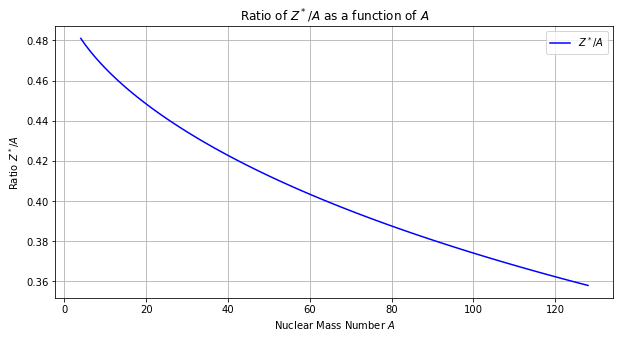

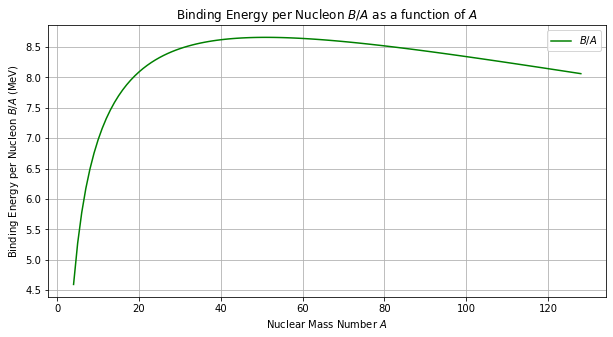

Optimal Z: 20, Optimal A: 51, Max B/A: 8.65913043091406 MeV


In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Constants from Table 5.1
aV = 15.5  # MeV
aA = 22.7  # MeV
aS = 16.6  # MeV
aC = 0.71  # MeV

# Expression for Z* as a function of A that maximizes binding energy
# Correct Z* function with debugging
def Z_star(A):
    numerator = 2 * aA * A
    denominator = 4 * aA + 2 * aC * A**(2/3)
    Z_star_continuous = numerator / denominator  # Continuous Z*
    return Z_star_continuous  # Rounded to nearest integer

# Binding energy per nucleon B/A as a function of Z* and A
def binding_energy_per_nucleon(Z, A):
    eta2 = (1 - 2 * Z / A)**2
    surface_term = aS * A**(2/3)
    coulomb_term = aC * Z**2 / A**(1/3)
    B = (aV - aA * eta2) * A - surface_term - coulomb_term
    return B / A

# Range of A values (mass numbers from 4 to 128)
A_values = np.arange(4, 129)  # A from 4 to 128
Z_star_values = Z_star(A_values)  # Calculate Z* for each A
Z_star_ratio = Z_star_values / A_values  # Calculate Z*/A

# Check that Z_star_values is not all zero
print("Z* values: ", Z_star_values)

# Calculate binding energy per nucleon for Z* and A
binding_energy_values = [binding_energy_per_nucleon(Z_star(A), A) for A in A_values]

# Find maximum B/A and corresponding A and Z
max_index = np.argmax(binding_energy_values)
max_B_A = binding_energy_values[max_index]
optimal_A = A_values[max_index]
optimal_Z = Z_star(optimal_A)

# Plot Z*/A as a function of A
plt.figure(figsize=(10, 5))
plt.plot(A_values, Z_star_ratio, label=r'$Z^*/A$', color='blue')
plt.title(r'Ratio of $Z^*/A$ as a function of $A$')
plt.xlabel(r'Nuclear Mass Number $A$')
plt.ylabel(r'Ratio $Z^*/A$')
plt.grid(True)
plt.legend()
plt.show()

# Plot B/A as a function of A
plt.figure(figsize=(10, 5))
plt.plot(A_values, binding_energy_values, label=r'$B/A$', color='green')
plt.title(r'Binding Energy per Nucleon $B/A$ as a function of $A$')
plt.xlabel(r'Nuclear Mass Number $A$')
plt.ylabel(r'Binding Energy per Nucleon $B/A$ (MeV)')
plt.grid(True)
plt.legend()
plt.show()

# Output the optimal values
print(f"Optimal Z: {int(optimal_Z)}, Optimal A: {int(optimal_A)}, Max B/A: {max_B_A} MeV")
